# BARseq gene-panel overlap

A1 includes a crossed within-animal design and a two-real-animal panel-aligned stress test; M1 uses crossed pseudo-panels within its single animal.

In every same-budget arm, each cell sees exactly the resolved `K` genes from
panel A or B. At 100% overlap, both groups see the *same K genes*; they do
not suddenly see every source gene. The separately labeled all-`P`-gene
oracle is the only arm that exposes every original gene. Only input
expression is hidden; projection targets, target labels, measurement masks,
calibration rows and outer test cells are unchanged. Fold-specific scaling
reads only expression values visible in training. Missing values become zero
after centering, meaning the visible-training mean rather than biological zero.

Primary comparisons are mask-aware union PU, PU-MIRT and PU-Joint. Controls
include intersection-only PU, a one-fit disjoint-coefficient PU control,
the same-K 100% endpoint, and an all-gene PU oracle. Shared-A versus
Separate-A MIRT is enabled by default as a matched pooled-fit ablation:
its two arms differ only in whether the duplicated A/B gene blocks share
one target-loading matrix. Panel/eligible-animal target offsets live in
a separate nuisance design and use the same fixed stabilization in every
primary model. Two fully independent panel calibrations/fits are deliberately
not exposed here: they change both pooling and calibration and therefore do
not isolate target-loading sharing. RF is disabled and is never scheduled.

Run top to bottom in the OnDemand environment. Change `OVERLAP_GRID` in the
first code cell if needed. Compact diagnostics remain on by default; complete
tables are always written to CSV.


## Configuration


In [1]:
from pathlib import Path
import os

# Change this list before Run All. Realized overlap is also reported because
# odd panel sizes (for example BARseq K=11) require integer gene counts.
OVERLAP_GRID = [0.0, 0.25, 0.50, 0.75, 1.0]
PANEL_SIZE = None  # None uses floor(number_of_genes / 2).
INCLUDE_CONTROLS = True
INCLUDE_SHARED_A_ABLATION = True

# Fixed, model-identical stabilization for the separate panel/animal-by-target
# nuisance coefficients. It is not part of the hyperparameter search.
NUISANCE_L2 = 1e-4

N_OUTER_FOLDS = 3
N_REPETITIONS = 4
N_JOBS = 32
PARALLEL_UNIT = 'scenario'
STRATEGY = 'full_joint'
CANDIDATE_BUDGET = 32
SEED = 20260910
PAIRED_FRACTION = 0.20
POSITIVE_LOSS_RATES = (0.0,)
USE_LOCATION = False
USE_TARGET_FEATURES = False

# RF is intentionally excluded from this experiment for now.
RUN_RANDOM_FOREST = False
RUN_INFORMATION_CONTROLS = False
RUN_QIAO = False

SHOW_PROGRESS = True
PROGRESS_LEVEL = 'summary'
PROGRESS_INTERVAL_SECONDS = 60.0
SHOW_FULL_DIAGNOSTICS = False

BASE_DIR = Path(os.environ.get('GENE2WIRE_PROJECT_DIR', '/home/yueyue/gene2wire')).expanduser()
RAW_DATA_DIR = BASE_DIR / 'raw_data'
CHECKPOINT_DIR = BASE_DIR / 'checkpoints' / 'gene_overlap_v2'
EXPORT_DIR = BASE_DIR / 'paper_figure_exports'
FIGURE_DIR = BASE_DIR / 'figures' / 'gene_overlap_0910'
CODE_CACHE_DIR = BASE_DIR / 'code'

RESULTS_ONLY = False
EXISTING_EXPORT_DIRS = {'BARseq A1 crossed': None, 'BARseq A1 animal-aligned': None, 'BARseq M1 crossed': None}  # Exact completed run directories or None.
EXPECTED_EXPORT_LABELS = ('BARseq A1 crossed', 'BARseq A1 animal-aligned', 'BARseq M1 crossed')
CORE_COMMIT = 'bd77d4103ff7aace7b16157c72b960953cf1a43b'
EXPECTED_SOURCE_HASH = '9ec276ca3560e004afeabf18e0d2dd9a665be0f61e86ab3e1df41bb02c75851a'
REPO_URL = 'https://github.com/Yue-stat/Gene2Wire.git'

for variable in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
                 'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[variable] = '1'

REQUIRED_MODULES = ['numpy', 'scipy', 'pandas', 'sklearn', 'joblib', 'threadpoolctl', 'matplotlib', 'yaml', 'IPython']
EXPECTED_PANEL_DESIGNS = {'BARseq A1 crossed': 'crossed', 'BARseq A1 animal-aligned': 'animal_aligned', 'BARseq M1 crossed': 'crossed'}


## Load and verify the pinned Gene2Wire core


In [2]:
import hashlib
import importlib.util
import re
import shutil
import subprocess
import sys
import tempfile

if sys.version_info < (3, 10):
    raise RuntimeError('Select an OnDemand Python 3.10 or newer kernel.')
if not re.fullmatch(r'[0-9a-f]{40}', CORE_COMMIT):
    raise RuntimeError('This notebook needs its released 40-character CORE_COMMIT pin.')
if not re.fullmatch(r'[0-9a-f]{64}', EXPECTED_SOURCE_HASH):
    raise RuntimeError('This notebook needs its released source checksum.')

def notebook_source_hash(package_root):
    # Same byte-level convention as experiments.protocol.source_hash().
    digest = hashlib.sha256()
    for source_path in sorted(package_root.rglob('*.py')):
        digest.update(source_path.relative_to(package_root).as_posix().encode())
        digest.update(source_path.read_bytes())
    return digest.hexdigest()

def verify_checkout(checkout, require_git_pin=True):
    package_root = checkout / 'src' / 'gene2wire'
    if not package_root.is_dir():
        raise RuntimeError(f'Missing Gene2Wire sources in {checkout}')
    if require_git_pin:
        actual_commit = subprocess.check_output(
            ['git', '-C', str(checkout), 'rev-parse', 'HEAD'], text=True).strip()
        if actual_commit != CORE_COMMIT:
            raise RuntimeError(f'Cached code has commit {actual_commit}, expected {CORE_COMMIT}.')
    if notebook_source_hash(package_root) != EXPECTED_SOURCE_HASH:
        raise RuntimeError(f'Source checksum mismatch in {checkout}; use the released code.')
    return checkout

# Running from the exact local repository is supported without any network call.
CORE_CHECKOUT = None
for candidate in (Path.cwd(), *Path.cwd().parents):
    package_root = candidate / 'src' / 'gene2wire'
    if package_root.is_dir() and notebook_source_hash(package_root) == EXPECTED_SOURCE_HASH:
        CORE_CHECKOUT = verify_checkout(candidate, require_git_pin=False)
        break

if CORE_CHECKOUT is None:
    CODE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    cached_checkout = CODE_CACHE_DIR / CORE_COMMIT
    if not cached_checkout.exists():
        stage = Path(tempfile.mkdtemp(prefix='.gene2wire-download-', dir=CODE_CACHE_DIR))
        try:
            for arguments in (
                ['git', 'init', '--quiet', str(stage)],
                ['git', '-C', str(stage), 'remote', 'add', 'origin', REPO_URL],
                ['git', '-C', str(stage), 'fetch', '--quiet', '--depth', '1', 'origin', CORE_COMMIT],
                ['git', '-C', str(stage), 'checkout', '--quiet', '--detach', 'FETCH_HEAD'],
            ):
                subprocess.run(arguments, check=True)
            verify_checkout(stage)
            try:
                stage.rename(cached_checkout)
            except OSError:
                # Another notebook may have completed this same immutable cache.
                if not cached_checkout.exists():
                    raise
                verify_checkout(cached_checkout)
        finally:
            if stage.exists():
                shutil.rmtree(stage)
    CORE_CHECKOUT = verify_checkout(cached_checkout)

existing = sys.modules.get('gene2wire')
if existing is not None:
    same_path = Path(existing.__file__).resolve().parent == (CORE_CHECKOUT / 'src' / 'gene2wire').resolve()
    same_source = getattr(existing, '_notebook_source_hash_0908', None) == EXPECTED_SOURCE_HASH
    if not (same_path and same_source):
        raise RuntimeError('A different or unverified gene2wire is already imported. Restart the kernel, then Run All.')

missing = [name for name in REQUIRED_MODULES if importlib.util.find_spec(name) is None]
if missing:
    raise RuntimeError('Use an OnDemand Python kernel containing these dependencies: '
                       + ', '.join(missing) + '. See the repository environment instructions.')
sys.path.insert(0, str(CORE_CHECKOUT / 'src'))
import gene2wire
from gene2wire.experiments.protocol import Settings, source_hash
if source_hash() != EXPECTED_SOURCE_HASH:
    raise RuntimeError('Imported code does not match the released source checksum.')
gene2wire._notebook_source_hash_0908 = EXPECTED_SOURCE_HASH
for directory in (RAW_DATA_DIR, CHECKPOINT_DIR, EXPORT_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)
print({'core_commit': CORE_COMMIT, 'source_hash': source_hash(),
       'imported_from': gene2wire.__file__, 'raw_cache': str(RAW_DATA_DIR),
       'checkpoints': str(CHECKPOINT_DIR), 'exports': str(EXPORT_DIR)})


{'core_commit': 'bd77d4103ff7aace7b16157c72b960953cf1a43b', 'source_hash': '9ec276ca3560e004afeabf18e0d2dd9a665be0f61e86ab3e1df41bb02c75851a', 'imported_from': '/home/yueyue/gene2wire/code/bd77d4103ff7aace7b16157c72b960953cf1a43b/src/gene2wire/__init__.py', 'raw_cache': '/home/yueyue/gene2wire/raw_data', 'checkpoints': '/home/yueyue/gene2wire/checkpoints/gene_overlap_v2', 'exports': '/home/yueyue/gene2wire/paper_figure_exports'}


## Shared model and overlap settings


In [3]:
from dataclasses import asdict
import numpy as np
import pandas as pd
from IPython.display import display
from gene2wire.experiments.protocol import Settings
from gene2wire.experiments.gene_overlap import (
    build_overlap_views, common_target_dataset, paired_group_folds,
    run_gene_overlap_experiment, validate_overlap_artifact,
)
from gene2wire.experiments.gene_overlap_plotting import plot_overlap_results
from gene2wire.experiments.reporting import (
    configure_full_display, configure_compact_display,
    load_existing_exports, display_diagnostics,
)

if SHOW_FULL_DIAGNOSTICS:
    configure_full_display()
else:
    configure_compact_display()

settings = Settings(
    n_outer_folds=N_OUTER_FOLDS, use_location=USE_LOCATION,
    use_target_features=USE_TARGET_FEATURES, n_jobs=N_JOBS,
    parallel_unit=PARALLEL_UNIT, n_repetitions=N_REPETITIONS,
    strategy=STRATEGY, candidate_budget=CANDIDATE_BUDGET, seed=SEED,
    paired_fraction=PAIRED_FRACTION, calibration_fractions=(PAIRED_FRACTION,),
    loss_rates=POSITIVE_LOSS_RATES,
    run_information_controls=RUN_INFORMATION_CONTROLS,
    run_random_forest=RUN_RANDOM_FOREST, run_qiao=RUN_QIAO,
    run_mechanism_controls=False, run_calibration_controls=False,
    nuisance_l2=NUISANCE_L2,
)
assert not RUN_RANDOM_FOREST and not settings.run_random_forest
assert not USE_LOCATION and not USE_TARGET_FEATURES
if SHOW_FULL_DIAGNOSTICS:
    display(pd.DataFrame([asdict(settings)]).T.rename(columns={0: 'settings'}))
else:
    print({'overlap_grid': OVERLAP_GRID, 'panel_size': PANEL_SIZE,
           'folds': N_OUTER_FOLDS, 'repetitions': N_REPETITIONS,
           'workers': N_JOBS, 'models': ['PU', 'PU-MIRT', 'PU-Joint'],
           'shared_A_ablation': INCLUDE_SHARED_A_ABLATION,
           'nuisance_l2': NUISANCE_L2,
           'random_forest': RUN_RANDOM_FOREST, 'positive_loss_rates': POSITIVE_LOSS_RATES})
if RESULTS_ONLY:
    all_artifacts = load_existing_exports(
        EXISTING_EXPORT_DIRS, expected_labels=EXPECTED_EXPORT_LABELS)
    for saved_label, saved_artifacts in all_artifacts.items():
        validate_overlap_artifact(
            saved_artifacts,
            expected_panel_design=EXPECTED_PANEL_DESIGNS[saved_label],
            expected_overlap_grid=OVERLAP_GRID,
            require_release_v2=True)
    print('RESULTS_ONLY: loading completed CSV/NPZ exports without raw-data loading or fitting.')


{'overlap_grid': [0.0, 0.25, 0.5, 0.75, 1.0], 'panel_size': None, 'folds': 3, 'repetitions': 4, 'workers': 32, 'models': ['PU', 'PU-MIRT', 'PU-Joint'], 'shared_A_ablation': True, 'nuisance_l2': 0.0001, 'random_forest': False, 'positive_loss_rates': (0.0,)}


## CPU allocation and active experiment workers


In [4]:
from gene2wire.experiments.workers import NotebookWorkerStatus

worker_status = None
if RESULTS_ONLY:
    print('RESULTS_ONLY: no training workers are launched.')
else:
    worker_status = NotebookWorkerStatus(requested_workers=N_JOBS)


## Outcome-independent design preview


In [5]:
def preview_overlap_views(label, views):
    first_rep = min(int(view.metadata['experiment_repetition']) for view in views)
    selected = [view for view in views
                if int(view.metadata['experiment_repetition']) == first_rep]
    rows = []
    for view in selected:
        context = view.metadata['experiment_context']
        arm = context['arm']
        panel_a = tuple(view.metadata['gene_overlap']['panel_A'])
        panel_b = tuple(view.metadata['gene_overlap']['panel_B'])
        source_gene_count = int(view.gene_matrix.shape[1])
        genes_per_cell = (source_gene_count if arm == 'all_gene_oracle'
                          else int(context['panel_size']))
        if arm == 'intersection':
            model_gene_columns = len(set(panel_a).intersection(panel_b))
        elif arm in {'disjoint_coefficient', 'shared_a', 'separate_a'}:
            model_gene_columns = 2 * int(context['panel_size'])
        elif arm == 'independent_panel':
            model_gene_columns = int(context['panel_size'])
        elif arm == 'all_gene_oracle':
            model_gene_columns = source_gene_count
        else:
            model_gene_columns = len(set(panel_a).union(panel_b))
        rows.append({
            'label': label, 'dataset': view.name,
            'design': context['panel_design'], 'arm': arm,
            'requested_overlap': context['requested_overlap'],
            'actual_overlap': context['actual_overlap'],
            'panel_size': context['panel_size'],
            'cells': len(view.cell_ids), 'targets': len(view.target_ids),
            'source_genes_P': source_gene_count,
            'available_genes_per_cell': genes_per_cell,
            'common_gene_count': len(set(panel_a).intersection(panel_b)),
            'union_gene_count': len(set(panel_a).union(panel_b)),
            'model_gene_columns': model_gene_columns,
            'panel_A_cells': int(np.sum(view.groups['overlap_panel'] == 'A')),
            'panel_B_cells': int(np.sum(view.groups['overlap_panel'] == 'B')),
            'models': ', '.join(view.metadata['model_allowlist']),
        })
    frame = pd.DataFrame(rows).drop_duplicates()
    display(frame)
    union = next(view for view in selected
                 if view.metadata['experiment_context']['arm'] == 'union')
    fold = union.split_builder(N_OUTER_FOLDS, SEED)[0]
    features = union.feature_builder(fold.train_rows, False, False)
    resolved_k = int(union.metadata['experiment_context']['panel_size'])
    source_p = int(union.gene_matrix.shape[1])
    print({
        'same_K_100pct_overlap': (
            f'both panels measure the same K={resolved_k} genes; this is not all {source_p} genes'),
        'all_P_gene_oracle': f'all P={source_p} genes are visible; plotted as a separate upper-bound point',
    })
    print({'first_fold_feature_shape': features.X.shape,
           'feature_blocks': dict(features.feature_blocks),
           'nuisance_shape': (None if features.X_nuisance is None
                              else features.X_nuisance.shape),
           'nuisance_names': tuple(features.nuisance_names),
           'targets_unchanged': True,
           'scaler_policy': 'visible outer-training expression only'})
    for checked_fold in union.split_builder(N_OUTER_FOLDS, SEED):
        for role, role_rows in (
                ('train', checked_fold.train_rows),
                ('validation', checked_fold.validation_rows),
                ('test', checked_fold.test_rows)):
            present = set(np.asarray(union.groups['overlap_panel'])[role_rows].astype(str))
            if present != {'A', 'B'}:
                raise ValueError(
                    f'Fold {checked_fold.outer_fold} {role} does not contain both gene panels')
    print('Fold audit: every train/validation/test role contains panels A and B.')
    if union.platform is not None and 'animal' in union.groups:
        animal_platform_panel = pd.DataFrame({
            'animal': np.asarray(union.groups['animal']).astype(str),
            'platform': np.asarray(union.platform).astype(str),
            'panel': np.asarray(union.groups['overlap_panel']).astype(str),
        }).drop_duplicates()
        if animal_platform_panel['animal'].duplicated().any():
            raise ValueError('Each Projection-TAGs animal must have one platform and one panel')
        platform_sets = animal_platform_panel.groupby('panel')['platform'].agg(lambda x: set(x))
        if len(platform_sets) != 2 or platform_sets.iloc[0] != platform_sets.iloc[1]:
            raise ValueError('Projection-TAGs panel assignment is confounded with platform')
        print('Animal-level platform × assigned gene-panel audit:')
        display(pd.crosstab(animal_platform_panel['panel'], animal_platform_panel['platform']))


In [6]:
def execute_views(label, views, export_name, run_settings=None):
    preview_overlap_views(label, views)
    return run_gene_overlap_experiment(
        views, settings if run_settings is None else run_settings,
        checkpoint_dir=CHECKPOINT_DIR, export_dir=EXPORT_DIR,
        export_name=export_name, progress=SHOW_PROGRESS,
        progress_interval=PROGRESS_INTERVAL_SECONDS,
        progress_level=PROGRESS_LEVEL, worker_status=worker_status)


## Load BARseq A1/M1 and construct gene panels


In [7]:
if not RESULTS_ONLY:
    from gene2wire.experiments.datasets.barseq import load_barseq
    datasets = load_barseq(RAW_DATA_DIR / 'BARseq')
    a1, m1 = datasets['A1'], datasets['M1']
    a1_crossed = build_overlap_views(
        a1, OVERLAP_GRID, panel_size=PANEL_SIZE,
        n_repetitions=N_REPETITIONS, panel_design='crossed',
        strata=('animal', 'slice'), include_controls=INCLUDE_CONTROLS,
        include_shared_a_ablation=INCLUDE_SHARED_A_ABLATION,
        nuisance_groups=('animal',),
        seed=SEED)
    animals = sorted(np.unique(a1.groups['animal']), key=str)
    if len(animals) != 2:
        raise ValueError('BARseq A1 animal-aligned design requires exactly two animals')
    a1_mapping = {animals[0]: 'A', animals[1]: 'B'}
    a1_aligned = build_overlap_views(
        a1, OVERLAP_GRID, panel_size=PANEL_SIZE,
        n_repetitions=N_REPETITIONS, panel_design='animal_aligned',
        aligned_group='animal', aligned_mapping=a1_mapping,
        include_controls=INCLUDE_CONTROLS,
        include_shared_a_ablation=INCLUDE_SHARED_A_ABLATION,
        seed=SEED)
    m1_crossed = build_overlap_views(
        m1, OVERLAP_GRID, panel_size=PANEL_SIZE,
        n_repetitions=N_REPETITIONS, panel_design='crossed',
        strata=('slice',), include_controls=INCLUDE_CONTROLS,
        include_shared_a_ablation=INCLUDE_SHARED_A_ABLATION,
        seed=SEED)


Loaded BARseq2 in 0.1s: 1,342 neurons, 23 genes, 46 targets, 3 animals


## Run A1 crossed, A1 aligned stress test, and M1 crossed


In [8]:
if not RESULTS_ONLY:
    all_artifacts = {
        'BARseq A1 crossed': execute_views('BARseq A1 crossed', a1_crossed,
                                           'BARseq_A1_crossed_gene_overlap_0910'),
        'BARseq A1 animal-aligned': execute_views('BARseq A1 animal-aligned', a1_aligned,
                                                  'BARseq_A1_animal_aligned_gene_overlap_0910'),
        'BARseq M1 crossed': execute_views('BARseq M1 crossed', m1_crossed,
                                           'BARseq_M1_crossed_gene_overlap_0910'),
    }


,label,dataset,design,arm,requested_overlap,actual_overlap,panel_size,cells,targets,source_genes_P,available_genes_per_cell,common_gene_count,union_gene_count,model_gene_columns,panel_A_cells,panel_B_cells,models
0,BARseq A1 crossed,BARseq A1,crossed,union,0.00,0.000000,11,593,11,23,11,0,22,22,305,288,"PU, PU-MIRT, PU-Joint"
1,BARseq A1 crossed,BARseq A1,crossed,intersection,0.00,0.000000,11,593,11,23,11,0,22,0,305,288,PU
2,BARseq A1 crossed,BARseq A1,crossed,disjoint_coefficient,0.00,0.000000,11,593,11,23,11,0,22,22,305,288,PU
3,BARseq A1 crossed,BARseq A1,crossed,shared_a,0.00,0.000000,11,593,11,23,11,0,22,22,305,288,PU-MIRT
4,BARseq A1 crossed,BARseq A1,crossed,separate_a,0.00,0.000000,11,593,11,23,11,0,22,22,305,288,PU-MIRT
5,BARseq A1 crossed,BARseq A1,crossed,union,0.25,0.272727,11,593,11,23,11,3,19,19,305,288,"PU, PU-MIRT, PU-Joint"
6,BARseq A1 crossed,BARseq A1,crossed,intersection,0.25,0.272727,11,593,11,23,11,3,19,3,305,288,PU
7,BARseq A1 crossed,BARseq A1,crossed,disjoint_coefficient,0.25,0.272727,11,593,11,23,11,3,19,22,305,288,PU
8,BARseq A1 crossed,BARseq A1,crossed,shared_a,0.25,0.272727,11,593,11,23,11,3,19,22,305,288,PU-MIRT
9,BARseq A1 crossed,BARseq A1,crossed,separate_a,0.25,0.272727,11,593,11,23,11,3,19,22,305,288,PU-MIRT


{'same_K_100pct_overlap': 'both panels measure the same K=11 genes; this is not all 23 genes', 'all_P_gene_oracle': 'all P=23 genes are visible; plotted as a separate upper-bound point'}
{'first_fold_feature_shape': (593, 22), 'feature_blocks': {'gene_union': (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21)}, 'nuisance_shape': (593, 2), 'nuisance_names': ('overlap_panel[B]', 'animal[A1_animal_2]'), 'targets_unchanged': True, 'scaler_policy': 'visible outer-training expression only'}
Fold audit: every train/validation/test role contains panels A and B.
[cache] verified result summaries 0/432; remaining 432 require cache checks or processing. Model/candidate/refit reuse is counted during execution; unchecked does not mean uncached.
[running 1min] finished units 381/432, current time 2026-09-10 21:23:52 PDT; restored results 0, reused fits 0, new/mixed 381
[finished 1min] finished units 432/432, current time 2026-09-10 21:24:03 PDT; restored results 0, reused

,label,dataset,design,arm,requested_overlap,actual_overlap,panel_size,cells,targets,source_genes_P,available_genes_per_cell,common_gene_count,union_gene_count,model_gene_columns,panel_A_cells,panel_B_cells,models
0,BARseq A1 animal-aligned,BARseq A1,animal_aligned,union,0.00,0.000000,11,593,11,23,11,0,22,22,300,293,"PU, PU-MIRT, PU-Joint"
1,BARseq A1 animal-aligned,BARseq A1,animal_aligned,intersection,0.00,0.000000,11,593,11,23,11,0,22,0,300,293,PU
2,BARseq A1 animal-aligned,BARseq A1,animal_aligned,disjoint_coefficient,0.00,0.000000,11,593,11,23,11,0,22,22,300,293,PU
3,BARseq A1 animal-aligned,BARseq A1,animal_aligned,shared_a,0.00,0.000000,11,593,11,23,11,0,22,22,300,293,PU-MIRT
4,BARseq A1 animal-aligned,BARseq A1,animal_aligned,separate_a,0.00,0.000000,11,593,11,23,11,0,22,22,300,293,PU-MIRT
5,BARseq A1 animal-aligned,BARseq A1,animal_aligned,union,0.25,0.272727,11,593,11,23,11,3,19,19,300,293,"PU, PU-MIRT, PU-Joint"
6,BARseq A1 animal-aligned,BARseq A1,animal_aligned,intersection,0.25,0.272727,11,593,11,23,11,3,19,3,300,293,PU
7,BARseq A1 animal-aligned,BARseq A1,animal_aligned,disjoint_coefficient,0.25,0.272727,11,593,11,23,11,3,19,22,300,293,PU
8,BARseq A1 animal-aligned,BARseq A1,animal_aligned,shared_a,0.25,0.272727,11,593,11,23,11,3,19,22,300,293,PU-MIRT
9,BARseq A1 animal-aligned,BARseq A1,animal_aligned,separate_a,0.25,0.272727,11,593,11,23,11,3,19,22,300,293,PU-MIRT


{'same_K_100pct_overlap': 'both panels measure the same K=11 genes; this is not all 23 genes', 'all_P_gene_oracle': 'all P=23 genes are visible; plotted as a separate upper-bound point'}
{'first_fold_feature_shape': (593, 22), 'feature_blocks': {'gene_union': (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21)}, 'nuisance_shape': (593, 1), 'nuisance_names': ('overlap_panel[B]',), 'targets_unchanged': True, 'scaler_policy': 'visible outer-training expression only'}
Fold audit: every train/validation/test role contains panels A and B.
[cache] verified result summaries 0/432; remaining 432 require cache checks or processing. Model/candidate/refit reuse is counted during execution; unchecked does not mean uncached.
[running 1min] finished units 432/432, current time 2026-09-10 21:25:19 PDT; restored results 0, reused fits 0, new/mixed 432
[finished 1min] finished units 432/432, current time 2026-09-10 21:25:21 PDT; restored results 0, reused fits 0, new/mixed 432

,label,dataset,design,arm,requested_overlap,actual_overlap,panel_size,cells,targets,source_genes_P,available_genes_per_cell,common_gene_count,union_gene_count,model_gene_columns,panel_A_cells,panel_B_cells,models
0,BARseq M1 crossed,BARseq M1,crossed,union,0.00,0.000000,11,749,35,23,11,0,22,22,377,372,"PU, PU-MIRT, PU-Joint"
1,BARseq M1 crossed,BARseq M1,crossed,intersection,0.00,0.000000,11,749,35,23,11,0,22,0,377,372,PU
2,BARseq M1 crossed,BARseq M1,crossed,disjoint_coefficient,0.00,0.000000,11,749,35,23,11,0,22,22,377,372,PU
3,BARseq M1 crossed,BARseq M1,crossed,shared_a,0.00,0.000000,11,749,35,23,11,0,22,22,377,372,PU-MIRT
4,BARseq M1 crossed,BARseq M1,crossed,separate_a,0.00,0.000000,11,749,35,23,11,0,22,22,377,372,PU-MIRT
5,BARseq M1 crossed,BARseq M1,crossed,union,0.25,0.272727,11,749,35,23,11,3,19,19,377,372,"PU, PU-MIRT, PU-Joint"
6,BARseq M1 crossed,BARseq M1,crossed,intersection,0.25,0.272727,11,749,35,23,11,3,19,3,377,372,PU
7,BARseq M1 crossed,BARseq M1,crossed,disjoint_coefficient,0.25,0.272727,11,749,35,23,11,3,19,22,377,372,PU
8,BARseq M1 crossed,BARseq M1,crossed,shared_a,0.25,0.272727,11,749,35,23,11,3,19,22,377,372,PU-MIRT
9,BARseq M1 crossed,BARseq M1,crossed,separate_a,0.25,0.272727,11,749,35,23,11,3,19,22,377,372,PU-MIRT


{'same_K_100pct_overlap': 'both panels measure the same K=11 genes; this is not all 23 genes', 'all_P_gene_oracle': 'all P=23 genes are visible; plotted as a separate upper-bound point'}
{'first_fold_feature_shape': (749, 22), 'feature_blocks': {'gene_union': (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21)}, 'nuisance_shape': (749, 1), 'nuisance_names': ('overlap_panel[B]',), 'targets_unchanged': True, 'scaler_policy': 'visible outer-training expression only'}
Fold audit: every train/validation/test role contains panels A and B.
[cache] verified result summaries 0/432; remaining 432 require cache checks or processing. Model/candidate/refit reuse is counted during execution; unchecked does not mean uncached.
[running 1min] finished units 183/432, current time 2026-09-10 21:26:40 PDT; restored results 0, reused fits 0, new/mixed 183
[finished 1min] finished units 432/432, current time 2026-09-10 21:27:34 PDT; restored results 0, reused fits 0, new/mixed 432

## Figures, essential metrics, selected hyperparameters and diagnostics


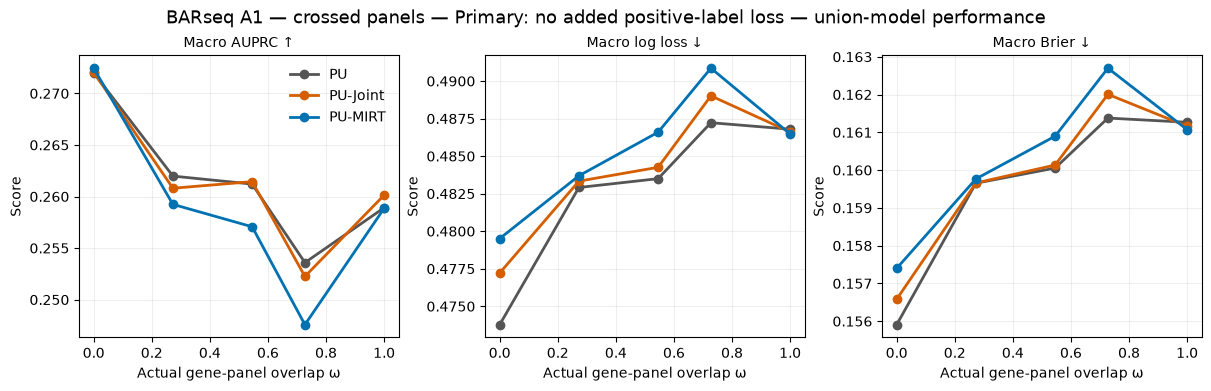

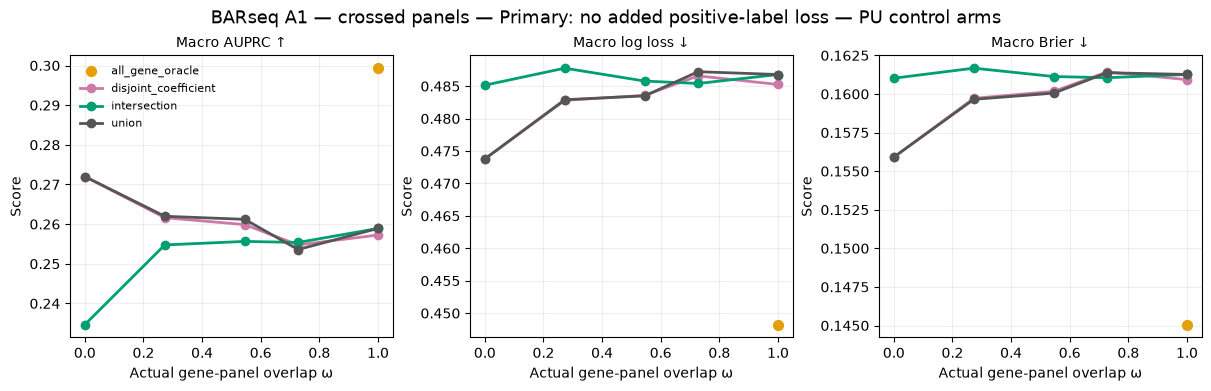

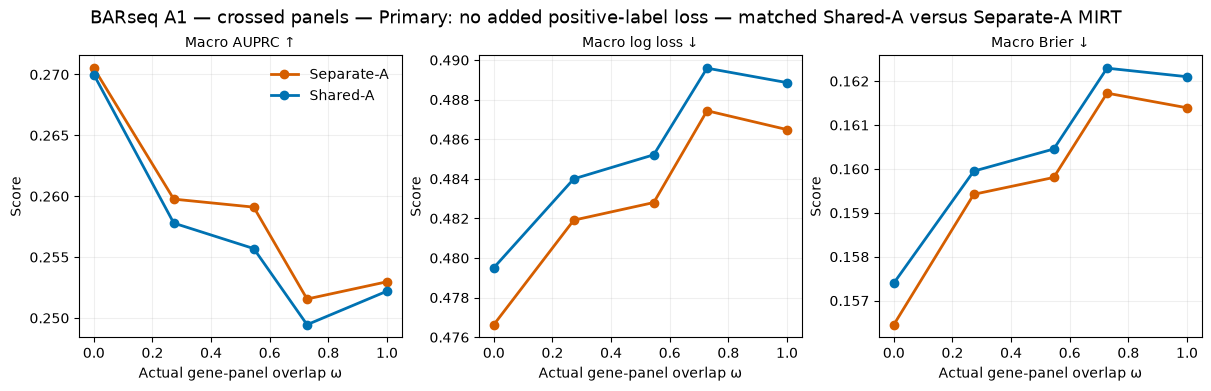

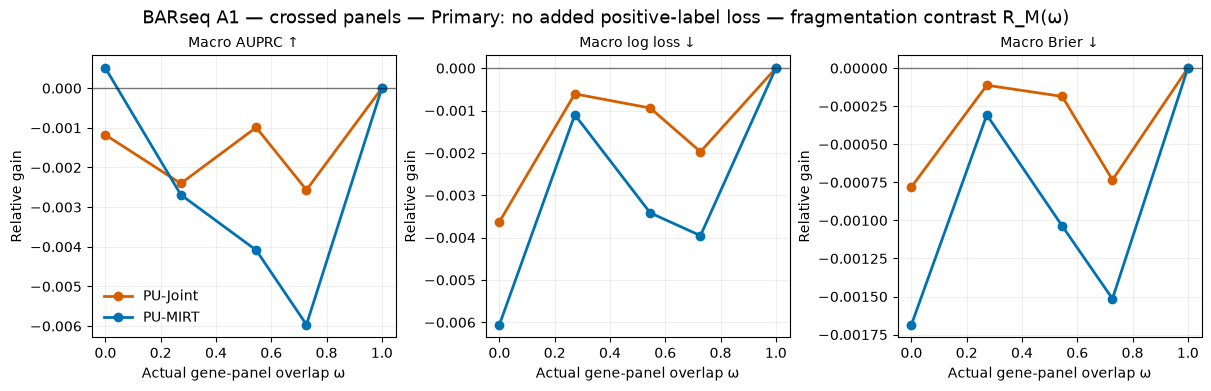

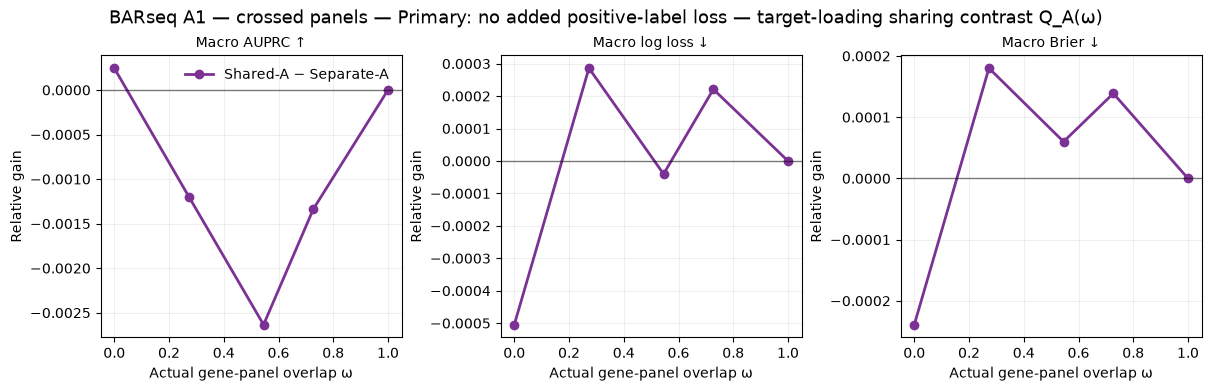


BARseq A1 crossed — concise diagnostics
All result tables, predictions and settings: /home/yueyue/gene2wire/paper_figure_exports/BARseq_A1_crossed_gene_overlap_0910/ba17549785d7ae407636
Saved run settings (authoritative for these results): {'n_outer_folds': 3, 'n_repetitions': 4, 'use_location': False, 'use_target_features': False, 'paired_fraction': 0.2, 'strategy': 'full_joint', 'candidate_budget': 32}
Execution settings recorded in this export: {'parallel_unit': 'scenario', 'requested_n_jobs': 32, 'effective_n_jobs': 32, 'scheduled_tasks': 312, 'planned_model_evaluations': 432, 'cached_model_evaluations': 0, 'reused_fit_model_evaluations': 0, 'new_or_mixed_model_evaluations': 432, 'unknown_fit_model_evaluations': 0}
Metric means give folds equal weight within each repetition, then repetitions equal weight. Endpoints use each model's largest recorded primary loss (or natural paired labels); block experiments use the largest block fraction and masked training. PU curves retain all pr

,arm,requested_overlap,actual_overlap,model,macro_auprc,macro_log_loss,macro_brier,hidden_recall_at_h,macro_hidden_recall_at_h,macro_predicted_prevalence,macro_reference_prevalence,worst_panel_macro_auprc,worst_panel_macro_log_loss,worst_panel_macro_brier
0,all_gene_oracle,1.00,1.000000,PU,0.299330,0.448223,0.145055,NaN,NaN,0.230199,0.221675,0.295256,0.460543,0.149394
1,disjoint_coefficient,0.00,0.000000,PU,0.271996,0.473775,0.155908,NaN,NaN,0.224157,0.221675,0.264861,0.489727,0.161749
2,disjoint_coefficient,0.25,0.272727,PU,0.261620,0.482814,0.159716,NaN,NaN,0.222575,0.221675,0.257964,0.496421,0.164890
3,disjoint_coefficient,0.50,0.545455,PU,0.259875,0.483583,0.160170,NaN,NaN,0.222852,0.221675,0.258128,0.495656,0.164644
4,disjoint_coefficient,0.75,0.727273,PU,0.254763,0.486585,0.161429,NaN,NaN,0.221963,0.221675,0.253763,0.498698,0.165721
5,disjoint_coefficient,1.00,1.000000,PU,0.257246,0.485260,0.160928,NaN,NaN,0.221817,0.221675,0.257590,0.497920,0.165470
6,intersection,0.00,0.000000,PU,0.234642,0.485151,0.161022,NaN,NaN,0.221861,0.221675,0.227047,0.496970,0.165414
7,intersection,0.25,0.272727,PU,0.254753,0.487774,0.161672,NaN,NaN,0.221033,0.221675,0.254835,0.499337,0.165870
8,intersection,0.50,0.545455,PU,0.255637,0.485784,0.161130,NaN,NaN,0.221992,0.221675,0.255611,0.497785,0.165412
9,intersection,0.75,0.727273,PU,0.255374,0.485410,0.161054,NaN,NaN,0.221770,0.221675,0.255889,0.498008,0.165610



pu_curves: showing 36/36 rows
Fixed coordinates: dataset=BARseq A1; sharing_strength=nan; analysis=primary; mechanism=technical_sar; loss_rate=0.0; calibration_fraction=0.2; calibration_spec=correct; experiment=gene_overlap; panel_design=crossed; panel_size=11; probability_semantics=reference


,arm,requested_overlap,actual_overlap,model,macro_auprc,macro_log_loss,macro_brier,hidden_recall_at_h
0,all_gene_oracle,1.00,1.000000,PU,0.299330,0.448223,0.145055,NaN
1,disjoint_coefficient,0.00,0.000000,PU,0.271996,0.473775,0.155908,NaN
2,disjoint_coefficient,0.25,0.272727,PU,0.261620,0.482814,0.159716,NaN
3,disjoint_coefficient,0.50,0.545455,PU,0.259875,0.483583,0.160170,NaN
4,disjoint_coefficient,0.75,0.727273,PU,0.254763,0.486585,0.161429,NaN
5,disjoint_coefficient,1.00,1.000000,PU,0.257246,0.485260,0.160928,NaN
6,intersection,0.00,0.000000,PU,0.234642,0.485151,0.161022,NaN
7,intersection,0.25,0.272727,PU,0.254753,0.487774,0.161672,NaN
8,intersection,0.50,0.545455,PU,0.255637,0.485784,0.161130,NaN
9,intersection,0.75,0.727273,PU,0.255374,0.485410,0.161054,NaN



selected_hyperparameters_by_repetition: showing 60/144 rows
Fixed coordinates: dataset=BARseq A1; sharing_strength=nan; analysis=primary; mechanism=technical_sar; loss_rate=0.0; calibration_fraction=0.2; calibration_spec=correct; experiment=gene_overlap; panel_design=crossed; panel_size=11
Bounded, context-balanced preview: 84 rows omitted; 1/1 contexts shown. Use the complete CSV exports for all configurations/contexts.


...


detection_calibration: showing 24/26 rows
Fixed coordinates: dataset=BARseq A1; sharing_strength=nan; analysis=primary; mechanism=technical_sar; loss_rate=0.0; calibration_fraction=0.2; calibration_spec=correct; experiment=gene_overlap; panel_design=crossed; panel_size=11
Bounded, context-balanced preview: 2 rows omitted; 1/1 contexts shown. Use the complete CSV exports for all configurations/contexts.


,arm,requested_overlap,actual_overlap,detection_log_loss,detection_brier,detection_mean,detection_observed_rate,sensitivity_mae,sensitivity_rmse
0,all_gene_oracle,1.00,1.000000,9.999779e-13,0.0,1.0,1.0,0.0,0.0
1,disjoint_coefficient,0.00,0.000000,9.999779e-13,0.0,1.0,1.0,0.0,0.0
2,disjoint_coefficient,0.25,0.272727,9.999779e-13,0.0,1.0,1.0,0.0,0.0
3,disjoint_coefficient,0.50,0.545455,9.999779e-13,0.0,1.0,1.0,0.0,0.0
4,disjoint_coefficient,0.75,0.727273,9.999779e-13,0.0,1.0,1.0,0.0,0.0
5,disjoint_coefficient,1.00,1.000000,9.999779e-13,0.0,1.0,1.0,0.0,0.0
6,intersection,0.00,0.000000,9.999779e-13,0.0,1.0,1.0,0.0,0.0
7,intersection,0.25,0.272727,9.999779e-13,0.0,1.0,1.0,0.0,0.0
8,intersection,0.50,0.545455,9.999779e-13,0.0,1.0,1.0,0.0,0.0
9,intersection,0.75,0.727273,9.999779e-13,0.0,1.0,1.0,0.0,0.0



overlap_contrasts: showing 30/30 rows
Fixed coordinates: dataset=BARseq A1; sharing_strength=nan; analysis=primary; mechanism=technical_sar; loss_rate=0.0; calibration_fraction=0.2; calibration_spec=correct; experiment=gene_overlap; panel_design=crossed; panel_size=11


,actual_overlap,model,metric,mean_advantage_vs_PU,mean_R_vs_100pct,sd_R_vs_100pct,n_repetitions
0,0.000000,PU-Joint,macro_auprc,0.000048,-0.001179,0.004802,4
1,0.000000,PU-Joint,macro_brier,-0.000675,-0.000780,0.000369,4
2,0.000000,PU-Joint,macro_log_loss,-0.003442,-0.003626,0.002155,4
3,0.000000,PU-MIRT,macro_auprc,0.000451,0.000505,0.004527,4
4,0.000000,PU-MIRT,macro_brier,-0.001491,-0.001685,0.001560,4
5,0.000000,PU-MIRT,macro_log_loss,-0.005735,-0.006055,0.005051,4
6,0.272727,PU-Joint,macro_auprc,-0.001178,-0.002404,0.002178,4
7,0.272727,PU-Joint,macro_brier,-0.000006,-0.000112,0.000675,4
8,0.272727,PU-Joint,macro_log_loss,-0.000423,-0.000607,0.000609,4
9,0.272727,PU-MIRT,macro_auprc,-0.002742,-0.002688,0.003990,4


Recorded failed units: 0.
All scenarios, final-fit records: 432; not converged: 0; status not recorded: 0.
All scenarios, candidate records: 8472; not converged: 0; status not recorded: 0.
Compact output is capped at 8 tables / 300 rows / 14 columns. Set SHOW_FULL_DIAGNOSTICS=True to display every saved table and the full manifest.


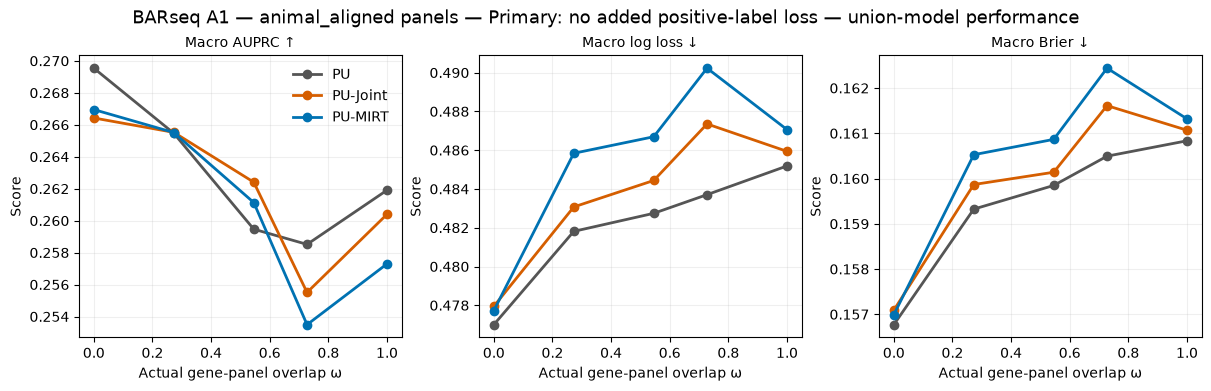

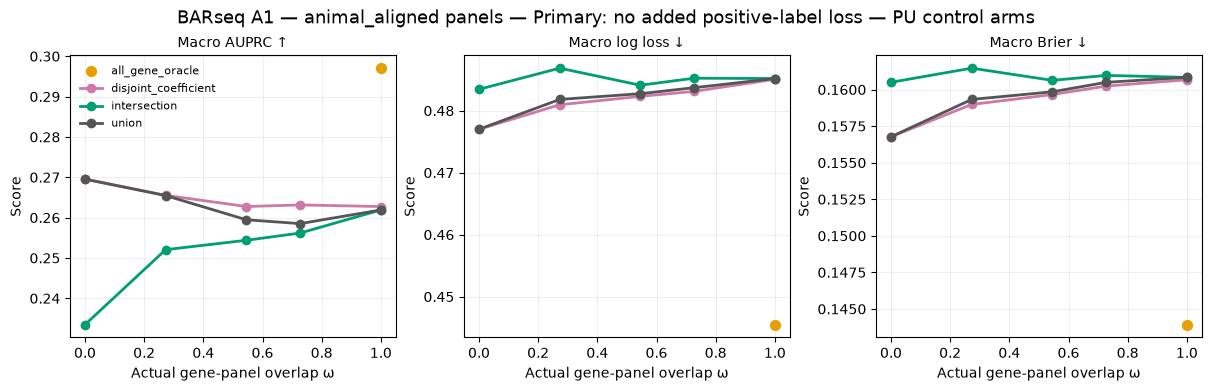

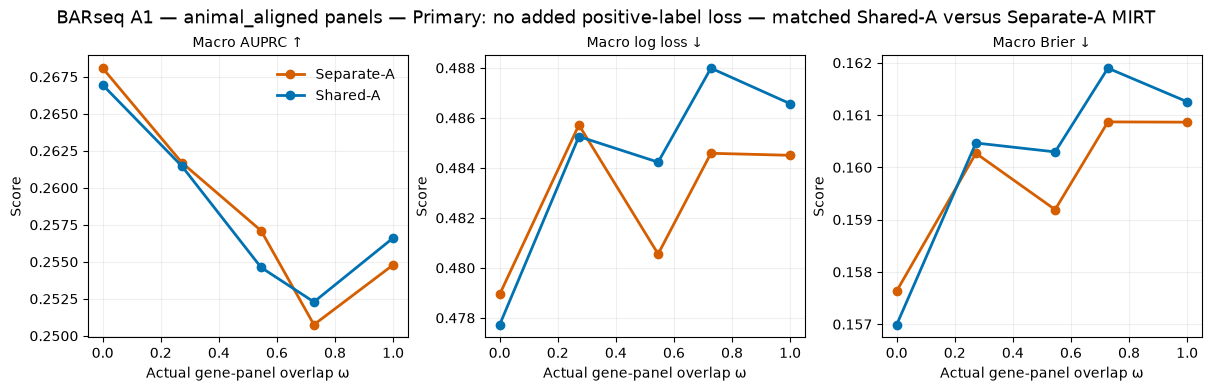

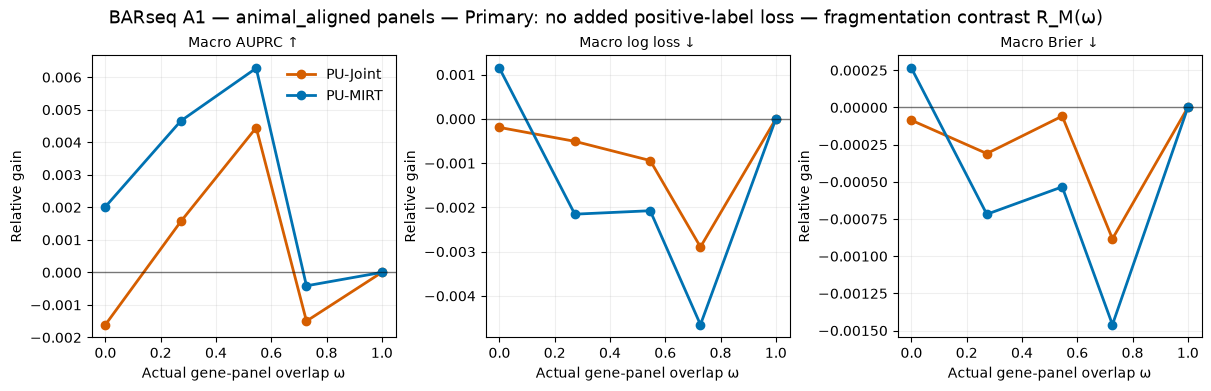

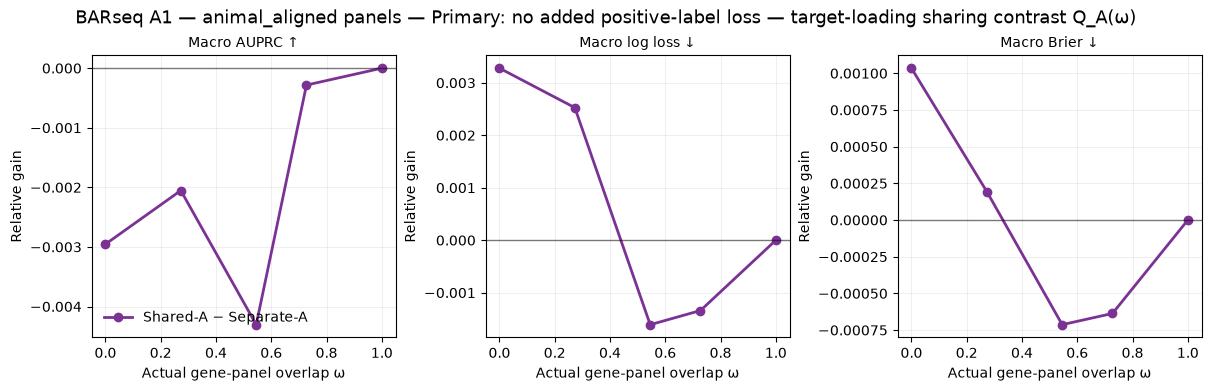


BARseq A1 animal-aligned — concise diagnostics
All result tables, predictions and settings: /home/yueyue/gene2wire/paper_figure_exports/BARseq_A1_animal_aligned_gene_overlap_0910/32ed684566b783145703
Saved run settings (authoritative for these results): {'n_outer_folds': 3, 'n_repetitions': 4, 'use_location': False, 'use_target_features': False, 'paired_fraction': 0.2, 'strategy': 'full_joint', 'candidate_budget': 32}
Execution settings recorded in this export: {'parallel_unit': 'scenario', 'requested_n_jobs': 32, 'effective_n_jobs': 32, 'scheduled_tasks': 312, 'planned_model_evaluations': 432, 'cached_model_evaluations': 0, 'reused_fit_model_evaluations': 0, 'new_or_mixed_model_evaluations': 432, 'unknown_fit_model_evaluations': 0}
Metric means give folds equal weight within each repetition, then repetitions equal weight. Endpoints use each model's largest recorded primary loss (or natural paired labels); block experiments use the largest block fraction and masked training. PU curves

,arm,requested_overlap,actual_overlap,model,macro_auprc,macro_log_loss,macro_brier,hidden_recall_at_h,macro_hidden_recall_at_h,macro_predicted_prevalence,macro_reference_prevalence,worst_panel_macro_auprc,worst_panel_macro_log_loss,worst_panel_macro_brier
0,all_gene_oracle,1.00,1.000000,PU,0.297040,0.445482,0.143925,NaN,NaN,0.229227,0.221675,0.268494,0.465095,0.150775
1,disjoint_coefficient,0.00,0.000000,PU,0.269540,0.477000,0.156771,NaN,NaN,0.224735,0.221675,0.251662,0.508156,0.168408
2,disjoint_coefficient,0.25,0.272727,PU,0.265524,0.480956,0.158981,NaN,NaN,0.222965,0.221675,0.250717,0.508466,0.169095
3,disjoint_coefficient,0.50,0.545455,PU,0.262752,0.482308,0.159659,NaN,NaN,0.223268,0.221675,0.250544,0.508572,0.169143
4,disjoint_coefficient,0.75,0.727273,PU,0.263143,0.483111,0.160239,NaN,NaN,0.223228,0.221675,0.253750,0.507149,0.169035
5,disjoint_coefficient,1.00,1.000000,PU,0.262749,0.485063,0.160668,NaN,NaN,0.222987,0.221675,0.253909,0.508189,0.169122
6,intersection,0.00,0.000000,PU,0.233470,0.483445,0.160496,NaN,NaN,0.221840,0.221675,0.209697,0.508702,0.169937
7,intersection,0.25,0.272727,PU,0.252061,0.486857,0.161463,NaN,NaN,0.220945,0.221675,0.237302,0.512403,0.170872
8,intersection,0.50,0.545455,PU,0.254385,0.484107,0.160628,NaN,NaN,0.221972,0.221675,0.238068,0.509473,0.170080
9,intersection,0.75,0.727273,PU,0.256179,0.485239,0.160969,NaN,NaN,0.221944,0.221675,0.241169,0.510207,0.170256



pu_curves: showing 36/36 rows
Fixed coordinates: dataset=BARseq A1; sharing_strength=nan; analysis=primary; mechanism=technical_sar; loss_rate=0.0; calibration_fraction=0.2; calibration_spec=correct; experiment=gene_overlap; panel_design=animal_aligned; panel_size=11; probability_semantics=reference


,arm,requested_overlap,actual_overlap,model,macro_auprc,macro_log_loss,macro_brier,hidden_recall_at_h
0,all_gene_oracle,1.00,1.000000,PU,0.297040,0.445482,0.143925,NaN
1,disjoint_coefficient,0.00,0.000000,PU,0.269540,0.477000,0.156771,NaN
2,disjoint_coefficient,0.25,0.272727,PU,0.265524,0.480956,0.158981,NaN
3,disjoint_coefficient,0.50,0.545455,PU,0.262752,0.482308,0.159659,NaN
4,disjoint_coefficient,0.75,0.727273,PU,0.263143,0.483111,0.160239,NaN
5,disjoint_coefficient,1.00,1.000000,PU,0.262749,0.485063,0.160668,NaN
6,intersection,0.00,0.000000,PU,0.233470,0.483445,0.160496,NaN
7,intersection,0.25,0.272727,PU,0.252061,0.486857,0.161463,NaN
8,intersection,0.50,0.545455,PU,0.254385,0.484107,0.160628,NaN
9,intersection,0.75,0.727273,PU,0.256179,0.485239,0.160969,NaN



selected_hyperparameters_by_repetition: showing 60/144 rows
Fixed coordinates: dataset=BARseq A1; sharing_strength=nan; analysis=primary; mechanism=technical_sar; loss_rate=0.0; calibration_fraction=0.2; calibration_spec=correct; experiment=gene_overlap; panel_design=animal_aligned; panel_size=11
Bounded, context-balanced preview: 84 rows omitted; 1/1 contexts shown. Use the complete CSV exports for all configurations/contexts.


...


detection_calibration: showing 24/26 rows
Fixed coordinates: dataset=BARseq A1; sharing_strength=nan; analysis=primary; mechanism=technical_sar; loss_rate=0.0; calibration_fraction=0.2; calibration_spec=correct; experiment=gene_overlap; panel_design=animal_aligned; panel_size=11
Bounded, context-balanced preview: 2 rows omitted; 1/1 contexts shown. Use the complete CSV exports for all configurations/contexts.


,arm,requested_overlap,actual_overlap,detection_log_loss,detection_brier,detection_mean,detection_observed_rate,sensitivity_mae,sensitivity_rmse
0,all_gene_oracle,1.00,1.000000,9.999779e-13,0.0,1.0,1.0,0.0,0.0
1,disjoint_coefficient,0.00,0.000000,9.999779e-13,0.0,1.0,1.0,0.0,0.0
2,disjoint_coefficient,0.25,0.272727,9.999779e-13,0.0,1.0,1.0,0.0,0.0
3,disjoint_coefficient,0.50,0.545455,9.999779e-13,0.0,1.0,1.0,0.0,0.0
4,disjoint_coefficient,0.75,0.727273,9.999779e-13,0.0,1.0,1.0,0.0,0.0
5,disjoint_coefficient,1.00,1.000000,9.999779e-13,0.0,1.0,1.0,0.0,0.0
6,intersection,0.00,0.000000,9.999779e-13,0.0,1.0,1.0,0.0,0.0
7,intersection,0.25,0.272727,9.999779e-13,0.0,1.0,1.0,0.0,0.0
8,intersection,0.50,0.545455,9.999779e-13,0.0,1.0,1.0,0.0,0.0
9,intersection,0.75,0.727273,9.999779e-13,0.0,1.0,1.0,0.0,0.0



overlap_contrasts: showing 30/30 rows
Fixed coordinates: dataset=BARseq A1; sharing_strength=nan; analysis=primary; mechanism=technical_sar; loss_rate=0.0; calibration_fraction=0.2; calibration_spec=correct; experiment=gene_overlap; panel_design=animal_aligned; panel_size=11


,actual_overlap,model,metric,mean_advantage_vs_PU,mean_R_vs_100pct,sd_R_vs_100pct,n_repetitions
0,0.000000,PU-Joint,macro_auprc,-0.003116,-0.001607,0.001990,4
1,0.000000,PU-Joint,macro_brier,-0.000320,-0.000086,0.000608,4
2,0.000000,PU-Joint,macro_log_loss,-0.000946,-0.000192,0.001268,4
3,0.000000,PU-MIRT,macro_auprc,-0.002591,0.002019,0.002290,4
4,0.000000,PU-MIRT,macro_brier,-0.000220,0.000264,0.001668,4
5,0.000000,PU-MIRT,macro_log_loss,-0.000728,0.001147,0.003726,4
6,0.272727,PU-Joint,macro_auprc,0.000057,0.001565,0.004269,4
7,0.272727,PU-Joint,macro_brier,-0.000543,-0.000310,0.000346,4
8,0.272727,PU-Joint,macro_log_loss,-0.001260,-0.000507,0.000424,4
9,0.272727,PU-MIRT,macro_auprc,0.000045,0.004655,0.007604,4


Recorded failed units: 0.
All scenarios, final-fit records: 432; not converged: 0; status not recorded: 0.
All scenarios, candidate records: 8472; not converged: 0; status not recorded: 0.
Compact output is capped at 8 tables / 300 rows / 14 columns. Set SHOW_FULL_DIAGNOSTICS=True to display every saved table and the full manifest.


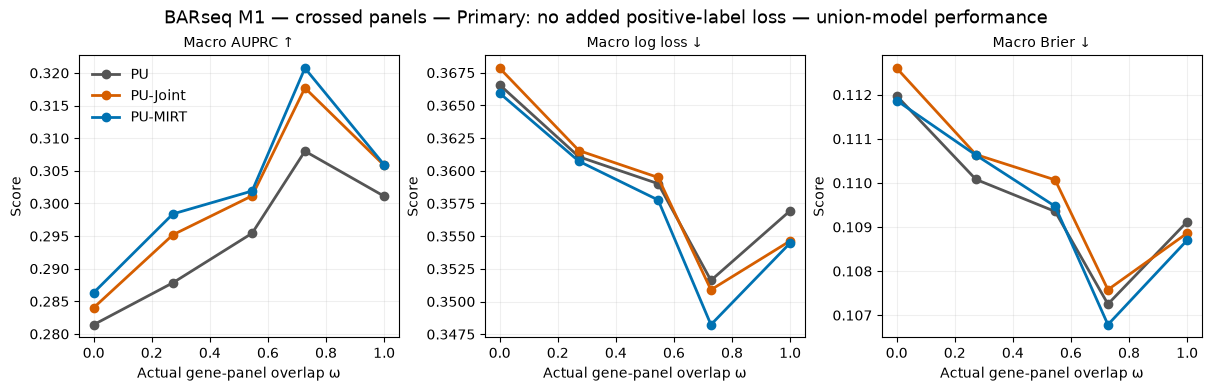

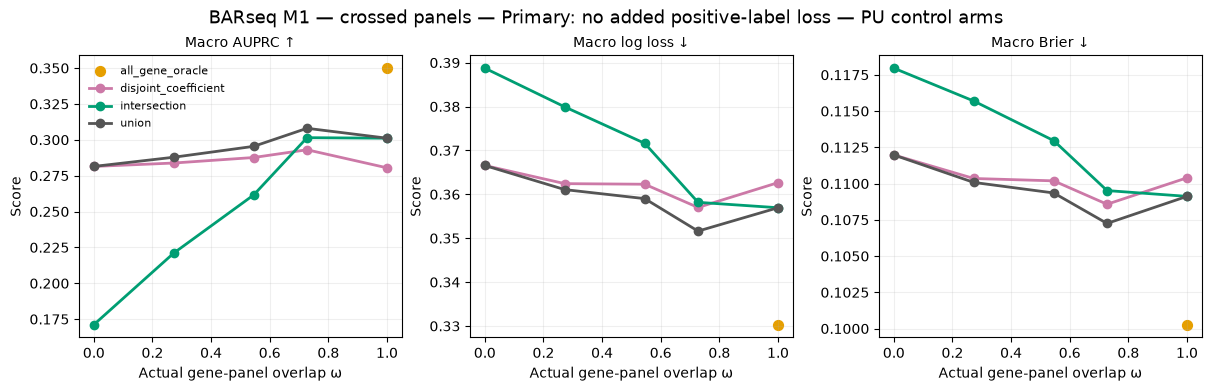

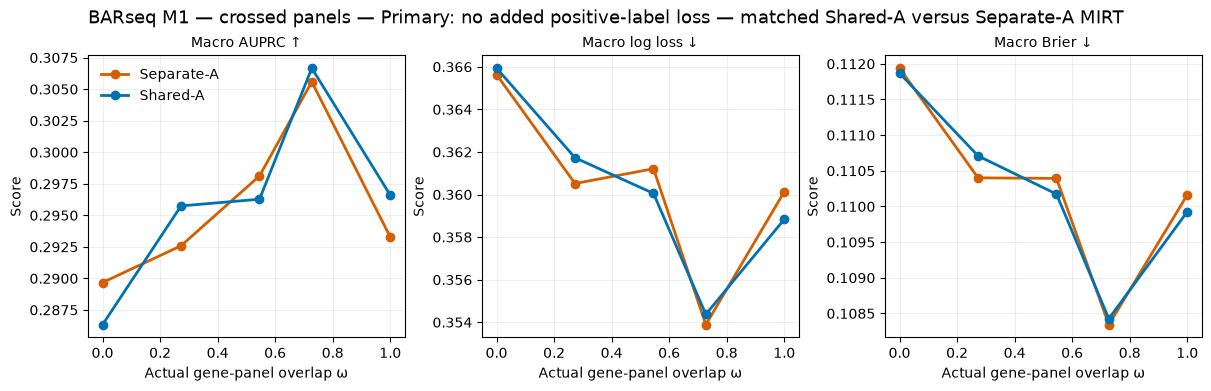

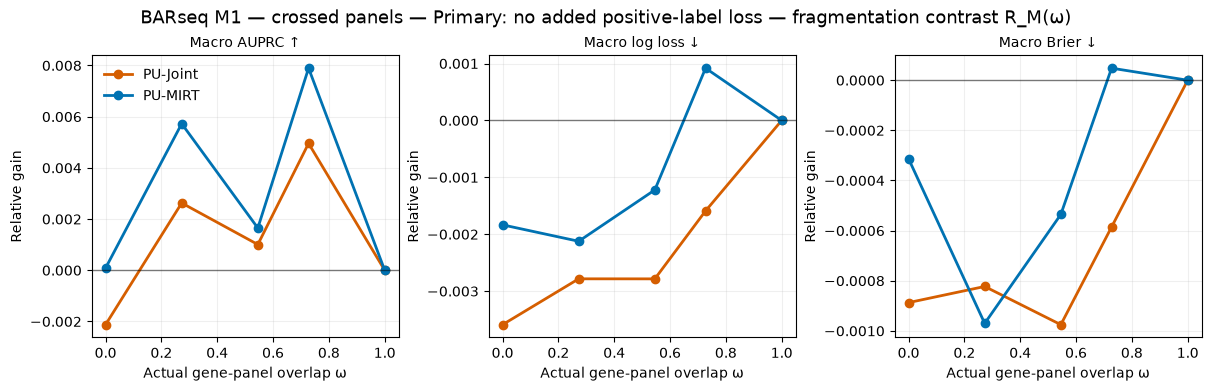

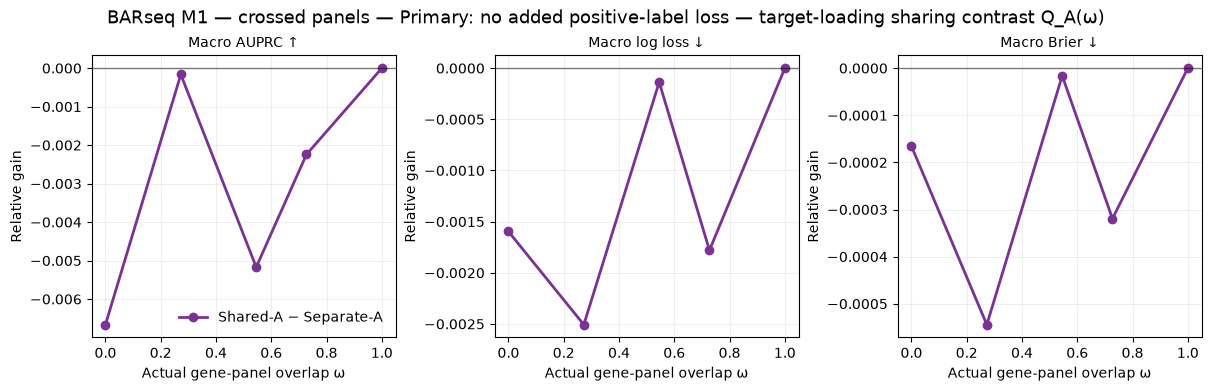


BARseq M1 crossed — concise diagnostics
All result tables, predictions and settings: /home/yueyue/gene2wire/paper_figure_exports/BARseq_M1_crossed_gene_overlap_0910/da07526957def8a9c239
Saved run settings (authoritative for these results): {'n_outer_folds': 3, 'n_repetitions': 4, 'use_location': False, 'use_target_features': False, 'paired_fraction': 0.2, 'strategy': 'full_joint', 'candidate_budget': 32}
Execution settings recorded in this export: {'parallel_unit': 'scenario', 'requested_n_jobs': 32, 'effective_n_jobs': 32, 'scheduled_tasks': 312, 'planned_model_evaluations': 432, 'cached_model_evaluations': 0, 'reused_fit_model_evaluations': 0, 'new_or_mixed_model_evaluations': 432, 'unknown_fit_model_evaluations': 0}
Metric means give folds equal weight within each repetition, then repetitions equal weight. Endpoints use each model's largest recorded primary loss (or natural paired labels); block experiments use the largest block fraction and masked training. PU curves retain all pr

,arm,requested_overlap,actual_overlap,model,macro_auprc,macro_log_loss,macro_brier,hidden_recall_at_h,macro_hidden_recall_at_h,macro_predicted_prevalence,macro_reference_prevalence,worst_panel_macro_auprc,worst_panel_macro_log_loss,worst_panel_macro_brier
0,all_gene_oracle,1.00,1.000000,PU,0.349918,0.330299,0.100271,NaN,NaN,0.174823,0.170878,0.356198,0.338323,0.102451
1,disjoint_coefficient,0.00,0.000000,PU,0.281424,0.366569,0.111974,NaN,NaN,0.173656,0.170878,0.274188,0.395932,0.121608
2,disjoint_coefficient,0.25,0.272727,PU,0.283805,0.362432,0.110351,NaN,NaN,0.173717,0.170878,0.273168,0.387434,0.118243
3,disjoint_coefficient,0.50,0.545455,PU,0.287651,0.362296,0.110188,NaN,NaN,0.172682,0.170878,0.281505,0.383816,0.116808
4,disjoint_coefficient,0.75,0.727273,PU,0.293043,0.357006,0.108575,NaN,NaN,0.172796,0.170878,0.295150,0.370253,0.112593
5,disjoint_coefficient,1.00,1.000000,PU,0.280460,0.362659,0.110397,NaN,NaN,0.172733,0.170878,0.299294,0.368221,0.112148
6,intersection,0.00,0.000000,PU,0.171143,0.388743,0.117958,NaN,NaN,0.170800,0.170878,0.170013,0.396757,0.120674
7,intersection,0.25,0.272727,PU,0.221052,0.379916,0.115692,NaN,NaN,0.173691,0.170878,0.231049,0.387988,0.118347
8,intersection,0.50,0.545455,PU,0.261588,0.371615,0.112961,NaN,NaN,0.172862,0.170878,0.273380,0.379162,0.115203
9,intersection,0.75,0.727273,PU,0.301468,0.358175,0.109517,NaN,NaN,0.174598,0.170878,0.315087,0.365823,0.111621



pu_curves: showing 36/36 rows
Fixed coordinates: dataset=BARseq M1; sharing_strength=nan; analysis=primary; mechanism=technical_sar; loss_rate=0.0; calibration_fraction=0.2; calibration_spec=correct; experiment=gene_overlap; panel_design=crossed; panel_size=11; probability_semantics=reference


,arm,requested_overlap,actual_overlap,model,macro_auprc,macro_log_loss,macro_brier,hidden_recall_at_h
0,all_gene_oracle,1.00,1.000000,PU,0.349918,0.330299,0.100271,NaN
1,disjoint_coefficient,0.00,0.000000,PU,0.281424,0.366569,0.111974,NaN
2,disjoint_coefficient,0.25,0.272727,PU,0.283805,0.362432,0.110351,NaN
3,disjoint_coefficient,0.50,0.545455,PU,0.287651,0.362296,0.110188,NaN
4,disjoint_coefficient,0.75,0.727273,PU,0.293043,0.357006,0.108575,NaN
5,disjoint_coefficient,1.00,1.000000,PU,0.280460,0.362659,0.110397,NaN
6,intersection,0.00,0.000000,PU,0.171143,0.388743,0.117958,NaN
7,intersection,0.25,0.272727,PU,0.221052,0.379916,0.115692,NaN
8,intersection,0.50,0.545455,PU,0.261588,0.371615,0.112961,NaN
9,intersection,0.75,0.727273,PU,0.301468,0.358175,0.109517,NaN



selected_hyperparameters_by_repetition: showing 60/144 rows
Fixed coordinates: dataset=BARseq M1; sharing_strength=nan; analysis=primary; mechanism=technical_sar; loss_rate=0.0; calibration_fraction=0.2; calibration_spec=correct; experiment=gene_overlap; panel_design=crossed; panel_size=11
Bounded, context-balanced preview: 84 rows omitted; 1/1 contexts shown. Use the complete CSV exports for all configurations/contexts.


...


overlap_contrasts: showing 30/30 rows
Fixed coordinates: dataset=BARseq M1; sharing_strength=nan; analysis=primary; mechanism=technical_sar; loss_rate=0.0; calibration_fraction=0.2; calibration_spec=correct; experiment=gene_overlap; panel_design=crossed; panel_size=11


,actual_overlap,model,metric,mean_advantage_vs_PU,mean_R_vs_100pct,sd_R_vs_100pct,n_repetitions
0,0.000000,PU-Joint,macro_auprc,0.002601,-0.002125,0.013174,4
1,0.000000,PU-Joint,macro_brier,-0.000628,-0.000887,0.001125,4
2,0.000000,PU-Joint,macro_log_loss,-0.001280,-0.003588,0.004494,4
3,0.000000,PU-MIRT,macro_auprc,0.004909,0.000085,0.014875,4
4,0.000000,PU-MIRT,macro_brier,0.000106,-0.000313,0.002812,4
5,0.000000,PU-MIRT,macro_log_loss,0.000634,-0.001835,0.008903,4
6,0.272727,PU-Joint,macro_auprc,0.007354,0.002628,0.008852,4
7,0.272727,PU-Joint,macro_brier,-0.000564,-0.000823,0.001165,4
8,0.272727,PU-Joint,macro_log_loss,-0.000474,-0.002783,0.004334,4
9,0.272727,PU-MIRT,macro_auprc,0.010550,0.005726,0.012964,4


Recorded failed units: 0.
All scenarios, final-fit records: 432; not converged: 0; status not recorded: 0.
All scenarios, candidate records: 8472; not converged: 0; status not recorded: 0.
Compact output is capped at 8 tables / 300 rows / 14 columns. Set SHOW_FULL_DIAGNOSTICS=True to display every saved table and the full manifest.


{'BARseq A1 crossed': [PosixPath('/home/yueyue/gene2wire/figures/gene_overlap_0910/BARseq_A1_crossed/BARseq_A1_crossed_crossed_primary.pdf'),
  PosixPath('/home/yueyue/gene2wire/figures/gene_overlap_0910/BARseq_A1_crossed/BARseq_A1_crossed_crossed_controls.pdf'),
  PosixPath('/home/yueyue/gene2wire/figures/gene_overlap_0910/BARseq_A1_crossed/BARseq_A1_crossed_crossed_shared_A_ablation.pdf'),
  PosixPath('/home/yueyue/gene2wire/figures/gene_overlap_0910/BARseq_A1_crossed/BARseq_A1_crossed_crossed_fragmentation_contrast.pdf'),
  PosixPath('/home/yueyue/gene2wire/figures/gene_overlap_0910/BARseq_A1_crossed/BARseq_A1_crossed_crossed_shared_A_contrast.pdf')],
 'BARseq A1 animal-aligned': [PosixPath('/home/yueyue/gene2wire/figures/gene_overlap_0910/BARseq_A1_animal-aligned/BARseq_A1_animal-aligned_animal_aligned_primary.pdf'),
  PosixPath('/home/yueyue/gene2wire/figures/gene_overlap_0910/BARseq_A1_animal-aligned/BARseq_A1_animal-aligned_animal_aligned_controls.pdf'),
  PosixPath('/home/yueyu

CSV/NPZ exports: {'BARseq A1 crossed': '/home/yueyue/gene2wire/paper_figure_exports/BARseq_A1_crossed_gene_overlap_0910/ba17549785d7ae407636', 'BARseq A1 animal-aligned': '/home/yueyue/gene2wire/paper_figure_exports/BARseq_A1_animal_aligned_gene_overlap_0910/32ed684566b783145703', 'BARseq M1 crossed': '/home/yueyue/gene2wire/paper_figure_exports/BARseq_M1_crossed_gene_overlap_0910/da07526957def8a9c239'}
Persistent checkpoints: /home/yueyue/gene2wire/checkpoints/gene_overlap_v2


In [9]:
figure_paths = {}
for label, artifacts in all_artifacts.items():
    paths = plot_overlap_results(
        artifacts, FIGURE_DIR / label.replace(' ', '_'),
        prefix=label.replace(' ', '_'), display=True)
    if not paths:
        raise RuntimeError(f'No gene-overlap figures were produced for {label!r}')
    figure_paths[label] = paths
    display_diagnostics(artifacts, label=label, full=SHOW_FULL_DIAGNOSTICS)
display(figure_paths)
print('CSV/NPZ exports:', {label: str(value.export_dir) for label, value in all_artifacts.items()})
print('Persistent checkpoints:', CHECKPOINT_DIR)
